In [1]:
import pathlib
import urllib
import shutil
from datetime import datetime, timedelta
import numpy as np
from numpy import ma
import pandas as pd
import xarray as xr
from scipy import ndimage as ndi
from scipy.stats import binned_statistic, binned_statistic_2d, circmean, circstd

import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib import patches
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
# Define some functions for analysis
def circmean_hour(x):
    return circmean(x, high=24, low=0)

def circstd_hour(x):
    return circstd(x, high=24, low=0)

def get_fractional_hour(x):
    return x.hour + x.minute/60 + x.second/3600

def add_gl_ticks(ax, gl):
    """
    Add tick marks to a cartopy gridliner object
    """
    x_tick_locs = []
    if gl.bottom_labels:
        x_tick_locs += [
            artist.properties()["unitless_position"][0]
            for artist in gl.bottom_label_artists
            if artist.properties()["visible"]
        ]
    if gl.top_labels:
        x_tick_locs += [
            artist.properties()["unitless_position"][0]
            for artist in gl.top_label_artists
            if artist.properties()["visible"]
        ]
    x_tick_labels = [""] * len(x_tick_locs)
    ax.set_xticks(x_tick_locs, crs=ax.projection)
    ax.set_xticklabels(x_tick_labels)

    y_tick_locs = []
    if gl.left_labels:
        y_tick_locs += [
            artist.properties()["unitless_position"][1]
            for artist in gl.left_label_artists
            if artist.properties()["visible"]
        ]
    if gl.right_labels:
        y_tick_locs += [
            artist.properties()["unitless_position"][1]
            for artist in gl.right_label_artists
            if artist.properties()["visible"]
        ]
    y_tick_labels = [""] * len(y_tick_locs)
    ax.set_yticks(y_tick_locs, crs=ax.projection)
    ax.set_yticklabels(y_tick_labels)

    ax.tick_params(
        top=gl.top_labels,
        bottom=gl.bottom_labels,
        left=gl.left_labels,
        right=gl.right_labels,
    )

def get_satellite_zenith_angle(lat, lon, sat_lat=0, sat_lon=0):
    Rgeo = 42_164
    Re = 6_371
    cos_beta = np.cos(np.radians(lat - sat_lat)) * np.cos(np.radians(lon - sat_lon))
    sin_theta = (Rgeo * np.sin(np.arccos(cos_beta))) / (Rgeo**2 + Re**2 - 2*Rgeo*Re*cos_beta)**0.5
    return np.degrees(np.arcsin(sin_theta))

In [3]:
seviri_2021_ds = xr.open_dataset('../data/seviri_tracking_2021.nc', decode_timedelta=True)
synsat_2021_ds = xr.open_dataset('../data/synsat_tracking_zoom9_2021.nc', decode_timedelta=True)
synsat_2033_ds = xr.open_dataset('../data/synsat_tracking_zoom9_2033.nc', decode_timedelta=True)

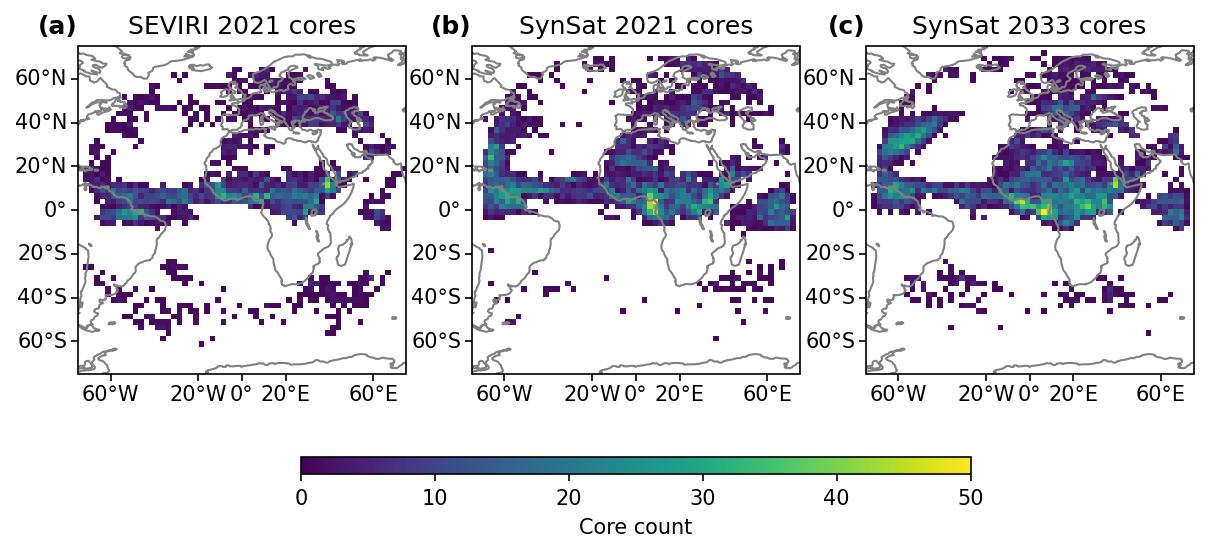

In [4]:
img_extent = (-75, 75, -75, 75)
bins=(np.arange(img_extent[0],img_extent[1]+1, 2.5), np.arange(img_extent[2],img_extent[3]+1, 2.5))
max_count = 50
min_count = 0

fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(9.6,4.8), dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))

# ax1.coastlines(color="grey")
# ax1.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
# gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
#                    linewidth=1, color='gray', alpha=0.5, linestyle='--')
# gl.top_labels = False
# gl.right_labels = False
# gl.xlines = False
# gl.ylines = False
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER

# h_data = np.histogram2d(
#     seviri_binned_ds.core_start_lon[seviri_binned_ds.core_is_valid], 
#     seviri_binned_ds.core_start_lat[seviri_binned_ds.core_is_valid], 
#     bins=bins,
# )[0]

# h_img = ax1.imshow(
#     ma.array(h_data, mask=h_data<=0).T[::-1],
#     extent=img_extent,
#     vmax=max_count, vmin=min_count,
#     interpolation="nearest"
# )

# ax1.set_title("(a)", loc="left", ha="right", weight="bold")
# ax1.set_title("SEVIRI (binned) cores", fontsize=12)

ax2.coastlines(color="grey")
ax2.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    seviri_2021_ds.core_start_lon[seviri_2021_ds.core_is_valid], 
    seviri_2021_ds.core_start_lat[seviri_2021_ds.core_is_valid], 
    bins=bins,
)[0]

h_img = ax2.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax2.set_title("(a)", loc="left", ha="right", weight="bold")
ax2.set_title("SEVIRI 2021 cores", fontsize=12)

ax3.coastlines(color="grey")
ax3.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    (synsat_2021_ds.core_start_lon[synsat_2021_ds.core_is_valid] + 180) % 360 - 180, 
    synsat_2021_ds.core_start_lat[synsat_2021_ds.core_is_valid], 
    bins=bins,
)[0]

h_img = ax3.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax3.set_title("(b)", loc="left", ha="right", weight="bold")
ax3.set_title("SynSat 2021 cores", fontsize=12)

ax4.coastlines(color="grey")
ax4.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    (synsat_2033_ds.core_start_lon[synsat_2033_ds.core_is_valid] + 180) % 360 - 180, 
    synsat_2033_ds.core_start_lat[synsat_2033_ds.core_is_valid], 
    bins=bins,
)[0]

h_img = ax4.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax4.set_title("(c)", loc="left", ha="right", weight="bold")
ax4.set_title("SynSat 2033 cores", fontsize=12)

fig.colorbar(h_img, ax=[ax2,ax3,ax4], shrink=0.6, location='bottom', label="Core count", aspect=40)

plt.draw()
# add_gl_ticks(ax1, gl)
add_gl_ticks(ax2, gl)
add_gl_ticks(ax3, gl)
add_gl_ticks(ax4, gl)

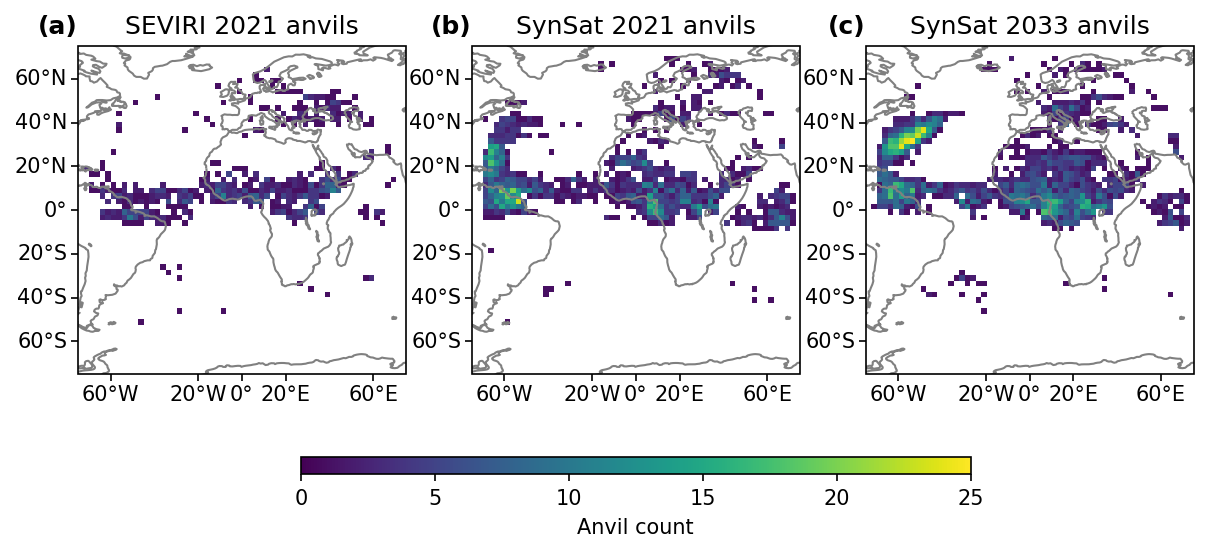

In [5]:
img_extent = (-75, 75, -75, 75)
bins=(np.arange(img_extent[0],img_extent[1]+1, 2.5), np.arange(img_extent[2],img_extent[3]+1, 2.5))
max_count = 25
min_count = 0

fig, (ax2, ax3, ax4) = plt.subplots(1, 3, figsize=(9.6,4.8), dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))

ax2.coastlines(color="grey")
ax2.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    seviri_2021_ds.thick_anvil_start_lon[seviri_2021_ds.thick_anvil_is_valid], 
    seviri_2021_ds.thick_anvil_start_lat[seviri_2021_ds.thick_anvil_is_valid], 
    bins=bins,
)[0]

h_img = ax2.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax2.set_title("(a)", loc="left", ha="right", weight="bold")
ax2.set_title("SEVIRI 2021 anvils", fontsize=12)

ax3.coastlines(color="grey")
ax3.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    (synsat_2021_ds.thick_anvil_start_lon[synsat_2021_ds.thick_anvil_is_valid] + 180) % 360 - 180, 
    synsat_2021_ds.thick_anvil_start_lat[synsat_2021_ds.thick_anvil_is_valid], 
    bins=bins,
)[0]

h_img = ax3.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax3.set_title("(b)", loc="left", ha="right", weight="bold")
ax3.set_title("SynSat 2021 anvils", fontsize=12)

ax4.coastlines(color="grey")
ax4.add_feature(cfeature.LAKES, edgecolor='grey', alpha=1, facecolor="none")
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                   linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

h_data = np.histogram2d(
    (synsat_2033_ds.thick_anvil_start_lon[synsat_2033_ds.thick_anvil_is_valid] + 180) % 360 - 180, 
    synsat_2033_ds.thick_anvil_start_lat[synsat_2033_ds.thick_anvil_is_valid], 
    bins=bins,
)[0]

h_img = ax4.imshow(
    ma.array(h_data, mask=h_data<=0).T[::-1],
    extent=img_extent,
    vmax=max_count, vmin=min_count,
    interpolation="nearest"
)

ax4.set_title("(c)", loc="left", ha="right", weight="bold")
ax4.set_title("SynSat 2033 anvils", fontsize=12)

fig.colorbar(h_img, ax=[ax2,ax3,ax4], shrink=0.6, location='bottom', label="Anvil count", aspect=40)

plt.draw()
add_gl_ticks(ax2, gl)
add_gl_ticks(ax3, gl)
add_gl_ticks(ax4, gl)

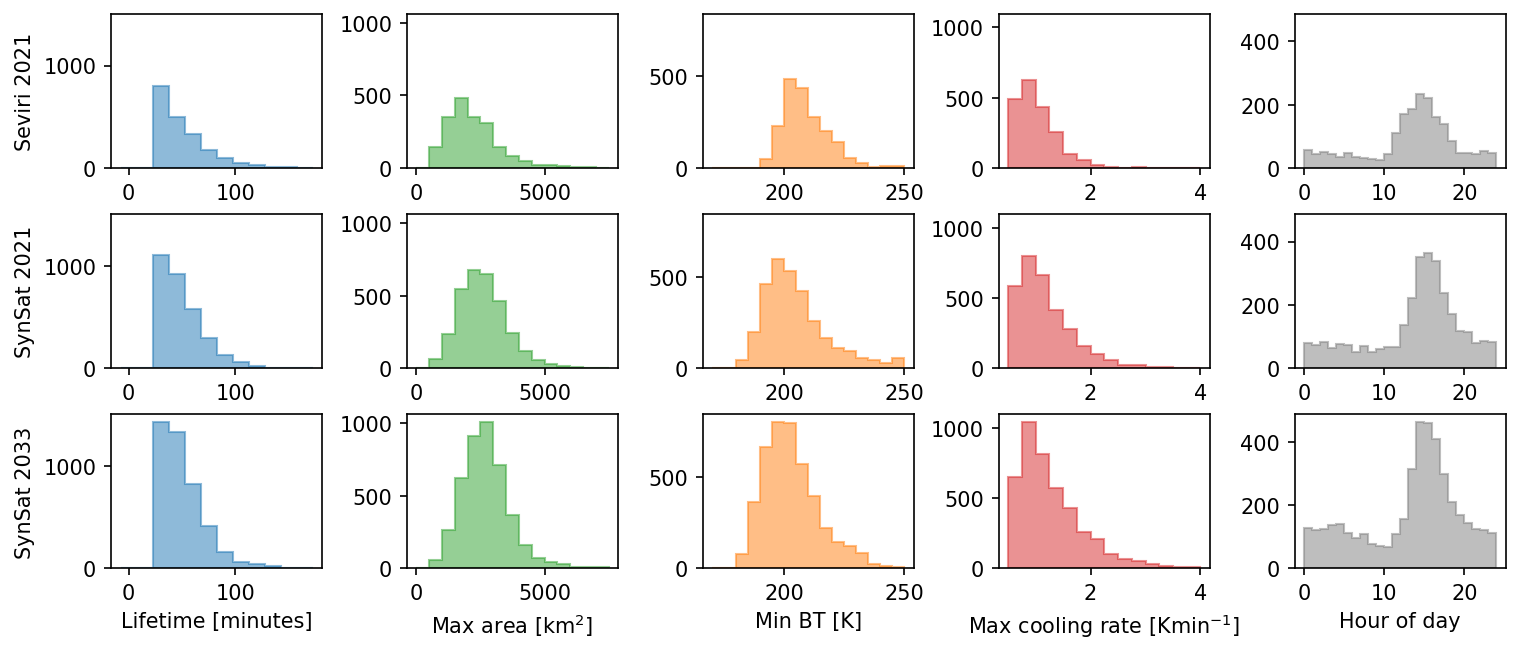

In [6]:
fig, ax = plt.subplots(3, 5, figsize=(12,4.8), dpi=150)

core_lifetime_bins = np.arange(0,185,15)-7.5
core_area_bins = np.arange(0,7501,500)
hour_bins = np.arange(25)
core_bt_bins = np.arange(170,251,5)
core_cooling_rate_bins = np.arange(0.5,4.1,0.25)

ax[0,0].hist(
    seviri_2021_ds.core_lifetime.astype(int)[
        seviri_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
    ]/6e10, 
    bins=core_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,0].hist(
    synsat_2021_ds.core_lifetime.astype(int)[
        synsat_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
    ]/6e10, 
    bins=core_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,0].hist(
    synsat_2033_ds.core_lifetime.astype(int)[
        synsat_2033_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
    ]/6e10, 
    bins=core_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,0].sharey(ax[0,0])
ax[2,0].sharey(ax[0,0])

# ax[0,0].axvline(
#     np.nanmean(seviri_2021_ds.core_lifetime.astype(int)[
#         seviri_2021_ds.core_is_valid 
#         & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
#     ]/60),
#     color="k", linestyle="--"
# )
# ax[1,0].axvline(
#     np.nanmean(synsat_2021_ds.core_lifetime.astype(int)[
#         synsat_2021_ds.core_is_valid 
#         & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
#     ]),
#     color="k", linestyle="--"
# )
# ax[2,0].axvline(
#     np.nanmean(synsat_2033_ds.core_lifetime.astype(int)[
#         synsat_2033_ds.core_is_valid 
#         & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
#     ]),
#     color="k", linestyle="--"
# )

ax[2,0].set_xlabel("Lifetime [minutes]")


ax[0,1].hist(
    seviri_2021_ds.core_max_area[
        seviri_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_area_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,1].hist(
    synsat_2021_ds.core_max_area[
        synsat_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_area_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,1].hist(
    synsat_2033_ds.core_max_area[
        synsat_2033_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
    ], 
    bins=core_area_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,1].set_xlabel("Max area [$\mathrm{km^2}$]")

ax[0,2].hist(
    seviri_2021_ds.core_bt_min[
        seviri_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,2].hist(
    synsat_2021_ds.core_bt_min[
        synsat_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,2].hist(
    synsat_2033_ds.core_bt_min[
        synsat_2033_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,2].set_xlabel("Min BT [K]")

ax[0,3].hist(
    seviri_2021_ds.core_max_cooling_rate[
        seviri_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_cooling_rate_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,3].hist(
    synsat_2021_ds.core_max_cooling_rate[
        synsat_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
    ], 
    bins=core_cooling_rate_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,3].hist(
    synsat_2033_ds.core_max_cooling_rate[
        synsat_2033_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
    ], 
    bins=core_cooling_rate_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,3].set_xlabel("Max cooling rate [$\mathrm{K min^{-1}}$]")

ax[0,4].hist(
    (seviri_2021_ds.core_start_t + np.array(seviri_2021_ds.core_start_lon/15*3600, "timedelta64[s]")).dt.hour[
        seviri_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.core_start_lat, seviri_2021_ds.core_start_lon) <= 45)
    ], 
    bins=hour_bins, 
    alpha=0.5, facecolor="C7", edgecolor="C7", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,4].hist(
    (synsat_2021_ds.core_start_t + np.array(synsat_2021_ds.core_start_lon/15*3600, "timedelta64[s]")).dt.hour[
        synsat_2021_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.core_start_lat, synsat_2021_ds.core_start_lon) <= 45)
    ], 
    bins=hour_bins, 
    alpha=0.5, facecolor="C7", edgecolor="C7", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,4].hist(
    (synsat_2033_ds.core_start_t + np.array(synsat_2033_ds.core_start_lon/15*3600, "timedelta64[s]")).dt.hour[
        synsat_2033_ds.core_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.core_start_lat, synsat_2033_ds.core_start_lon) <= 45)
    ], 
    bins=hour_bins, 
    alpha=0.5, facecolor="C7", edgecolor="C7", ls='solid', lw=3, histtype='stepfilled'
)
ax[2,4].set_xlabel("Hour of day")

ax[1,1].sharey(ax[0,1])
ax[2,1].sharey(ax[0,1])

ax[1,2].sharey(ax[0,2])
ax[2,2].sharey(ax[0,2])

ax[1,3].sharey(ax[0,3])
ax[2,3].sharey(ax[0,3])

ax[1,4].sharey(ax[0,4])
ax[2,4].sharey(ax[0,4])

ax[0,0].set_ylabel("Seviri 2021")
ax[1,0].set_ylabel("SynSat 2021")
ax[2,0].set_ylabel("SynSat 2033")

plt.subplots_adjust(wspace=0.4, hspace=0.3)

# ax1.set_title("(a)", loc="left", ha="right", weight="bold")
# ax1.set_title("SEVIRI (binned)", fontsize=12)
# ax2.set_title("(b)", loc="left", ha="right", weight="bold")
# ax2.set_title("SEVIRI (nearest)", fontsize=12)
# ax3.set_title("(c)", loc="left", ha="right", weight="bold")
# ax3.set_title("SynSat 2021", fontsize=12)
# ax4.set_title("(d)", loc="left", ha="right", weight="bold")
# ax4.set_title("SynSat 2033", fontsize=12)

# fig.suptitle("Core lifetime")


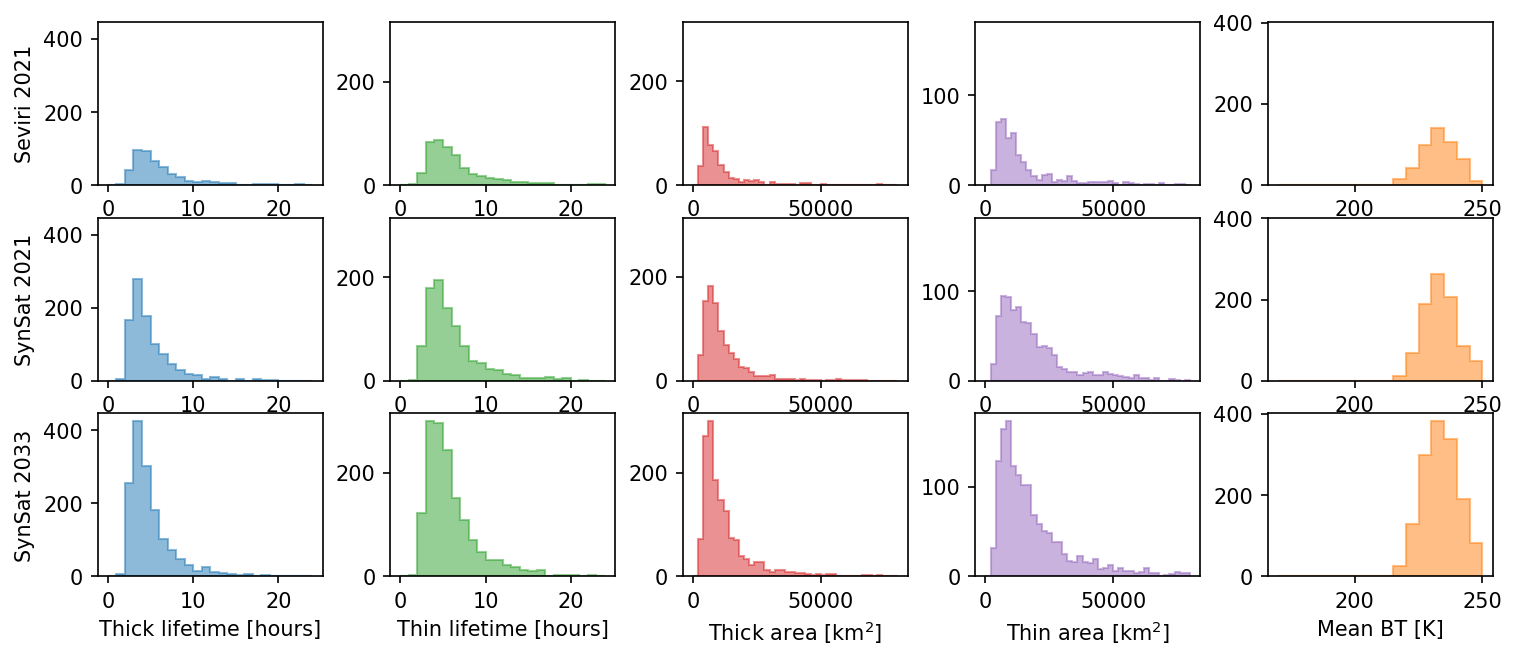

In [7]:
fig, ax = plt.subplots(3, 5, figsize=(12,4.8), dpi=150)

ax[0,0].set_ylabel("Seviri 2021")
ax[1,0].set_ylabel("SynSat 2021")
ax[2,0].set_ylabel("SynSat 2033")

ax[1,0].sharey(ax[0,0])
ax[2,0].sharey(ax[0,0])

ax[1,1].sharey(ax[0,1])
ax[2,1].sharey(ax[0,1])

ax[1,2].sharey(ax[0,2])
ax[2,2].sharey(ax[0,2])

ax[1,3].sharey(ax[0,3])
ax[2,3].sharey(ax[0,3])

ax[1,4].sharey(ax[0,4])
ax[2,4].sharey(ax[0,4])

thick_anvil_lifetime_bins = np.arange(25)

ax[0,0].hist(
    seviri_2021_ds.thick_anvil_lifetime.astype(int)[
        seviri_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.thick_anvil_start_lat, seviri_2021_ds.thick_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thick_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,0].hist(
    synsat_2021_ds.thick_anvil_lifetime.astype(int)[
        synsat_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.thick_anvil_start_lat, synsat_2021_ds.thick_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thick_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,0].hist(
    synsat_2033_ds.thick_anvil_lifetime.astype(int)[
        synsat_2033_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.thick_anvil_start_lat, synsat_2033_ds.thick_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thick_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C0", edgecolor="C0", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,0].set_xlabel("Thick lifetime [hours]")

thin_anvil_lifetime_bins = np.arange(25)

ax[0,1].hist(
    seviri_2021_ds.thin_anvil_lifetime.astype(int)[
        seviri_2021_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.thin_anvil_start_lat, seviri_2021_ds.thin_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thin_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,1].hist(
    synsat_2021_ds.thin_anvil_lifetime.astype(int)[
        synsat_2021_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.thin_anvil_start_lat, synsat_2021_ds.thin_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thin_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,1].hist(
    synsat_2033_ds.thin_anvil_lifetime.astype(int)[
        synsat_2033_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.thin_anvil_start_lat, synsat_2033_ds.thin_anvil_start_lon) <= 45)
    ]/3.6e12, 
    bins=thin_anvil_lifetime_bins, 
    alpha=0.5, facecolor="C2", edgecolor="C2", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,1].set_xlabel("Thin lifetime [hours]")

thick_anvil_area_bins = np.arange(0,80001,2000)

ax[0,2].hist(
    seviri_2021_ds.thick_anvil_max_area[
        seviri_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.thick_anvil_start_lat, seviri_2021_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=thick_anvil_area_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,2].hist(
    synsat_2021_ds.thick_anvil_max_area[
        synsat_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.thick_anvil_start_lat, synsat_2021_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=thick_anvil_area_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,2].hist(
    synsat_2033_ds.thick_anvil_max_area[
        synsat_2033_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.thick_anvil_start_lat, synsat_2033_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=thick_anvil_area_bins, 
    alpha=0.5, facecolor="C3", edgecolor="C3", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,2].set_xlabel("Thick area [$\mathrm{km^2}$]")

thin_anvil_area_bins = np.arange(0,80001,2000)

ax[0,3].hist(
    seviri_2021_ds.thin_anvil_max_area[
        seviri_2021_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.thin_anvil_start_lat, seviri_2021_ds.thin_anvil_start_lon) <= 45)
    ], 
    bins=thin_anvil_area_bins, 
    alpha=0.5, facecolor="C4", edgecolor="C4", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,3].hist(
    synsat_2021_ds.thin_anvil_max_area[
        synsat_2021_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.thin_anvil_start_lat, synsat_2021_ds.thin_anvil_start_lon) <= 45)
    ], 
    bins=thin_anvil_area_bins, 
    alpha=0.5, facecolor="C4", edgecolor="C4", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,3].hist(
    synsat_2033_ds.thin_anvil_max_area[
        synsat_2033_ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.thin_anvil_start_lat, synsat_2033_ds.thin_anvil_start_lon) <= 45)
    ], 
    bins=thin_anvil_area_bins, 
    alpha=0.5, facecolor="C4", edgecolor="C4", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,3].set_xlabel("Thin area [$\mathrm{km^2}$]")

ax[0,4].hist(
    seviri_2021_ds.thick_anvil_bt_mean[
        seviri_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(seviri_2021_ds.thick_anvil_start_lat, seviri_2021_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[1,4].hist(
    synsat_2021_ds.thick_anvil_bt_mean[
        synsat_2021_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2021_ds.thick_anvil_start_lat, synsat_2021_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,4].hist(
    synsat_2033_ds.thick_anvil_bt_mean[
        synsat_2033_ds.thick_anvil_is_valid 
        & (get_satellite_zenith_angle(synsat_2033_ds.thick_anvil_start_lat, synsat_2033_ds.thick_anvil_start_lon) <= 45)
    ], 
    bins=core_bt_bins, 
    alpha=0.5, facecolor="C1", edgecolor="C1", ls='solid', lw=3, histtype='stepfilled'
)

ax[2,4].set_xlabel("Mean BT [K]")

plt.subplots_adjust(wspace=0.3)

### Make more detailed plots with distributions

In [8]:
def histogram_with_boxplot(data, bins, ax=None, proportion=False, hist_kwargs=None, boxplot_kwargs=None, axes_kwargs=None, show_meanline=False, mean_func=np.nanmean, meanline_kwargs=None):
    if ax is None:
        ax = plt.gca()

    if hist_kwargs is None:
        hist_kwargs = {}

    if boxplot_kwargs is None:
        boxplot_kwargs = {}

    if axes_kwargs is None:
        axes_kwargs = {}
    if "size" not in axes_kwargs:
        axes_kwargs["size"]="20%"

    # Check and aligh orientation
    orientation = hist_kwargs["orientation"] if "orientation" in hist_kwargs else "vertical"
    if orientation not in ["horizontal", "vertical"]:
        raise ValueError("'orientation' must be either 'horizontal' or 'vertical'")
    boxplot_kwargs["orientation"] = "vertical" if  orientation == "horizontal" else "horizontal" # Needs to be opposite

    # Make axes divider and add new axes
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)

    if orientation == "vertical":
        ax2 = divider.append_axes("bottom", **axes_kwargs)
        ax2.sharex(ax)
    elif orientation == "horizontal":
        ax2 = divider.append_axes("left", **axes_kwargs)
        ax2.sharey(ax)

    ax2.set_axis_off()

    ax.get_figure().add_axes(ax2)

    if proportion:
        h = ax.hist(data, bins, weights=np.ones(data.shape)/data.size, **hist_kwargs)
    else:
        h = ax.hist(data, bins, **hist_kwargs)
    b = ax2.boxplot(data, **boxplot_kwargs)

    if show_meanline:
        if meanline_kwargs is None:
            meanline_kwargs = dict(color="k", linestyle="--")
        ax.axvline(mean_func(data), **meanline_kwargs)
    return h, b
    

In [52]:
def core_is_valid(ds, max_zenith_angle=45, max_bt=245):
    return (
        ds.core_is_valid 
        & (get_satellite_zenith_angle(ds.core_start_lat, ds.core_start_lon) <= max_zenith_angle)
        & (ds.core_bt_min <= max_bt)
    )

def anvil_is_valid(ds, max_zenith_angle=45):
    return (
        ds.thick_anvil_is_valid 
        & ds.thin_anvil_is_valid 
        & (get_satellite_zenith_angle(ds.thick_anvil_start_lat, ds.thick_anvil_start_lon) <= max_zenith_angle)
        & core_is_valid(ds).loc[ds.anvil_initial_core_index]
    )

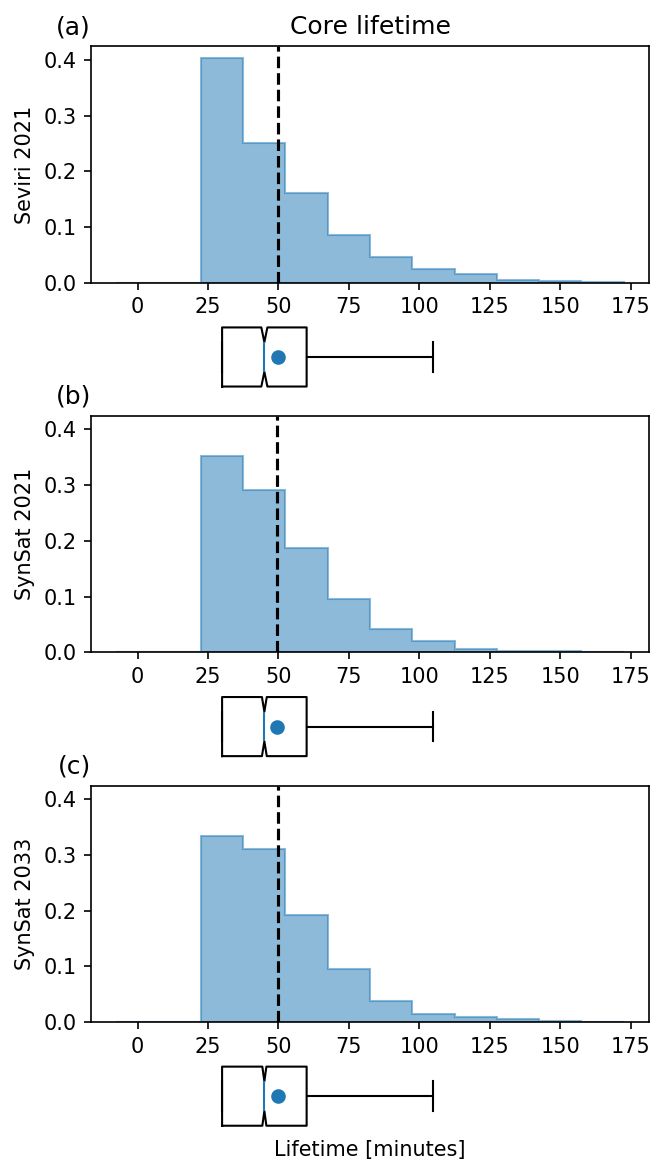

In [10]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 1, figsize=(4.8, 9.6), dpi=150, sharey=True)

color = "C0"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

axes[0].set_ylabel("Seviri 2021")
axes[1].set_ylabel("SynSat 2021")
axes[2].set_ylabel("SynSat 2033")

axes[2].set_xlabel("Lifetime [minutes]", labelpad=40)

axes[0].set_title("Core lifetime", pad=20)

axes[0].set_title("(a)", loc="left", ha="right")
axes[1].set_title("(b)", loc="left", ha="right")
axes[2].set_title("(c)", loc="left", ha="right")

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    histogram_with_boxplot(
        ds.core_lifetime.astype(int)[core_is_valid(ds)]/6e10, 
        bins=core_lifetime_bins,
        proportion=True, 
        ax=ax, 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

plt.subplots_adjust(hspace=0)

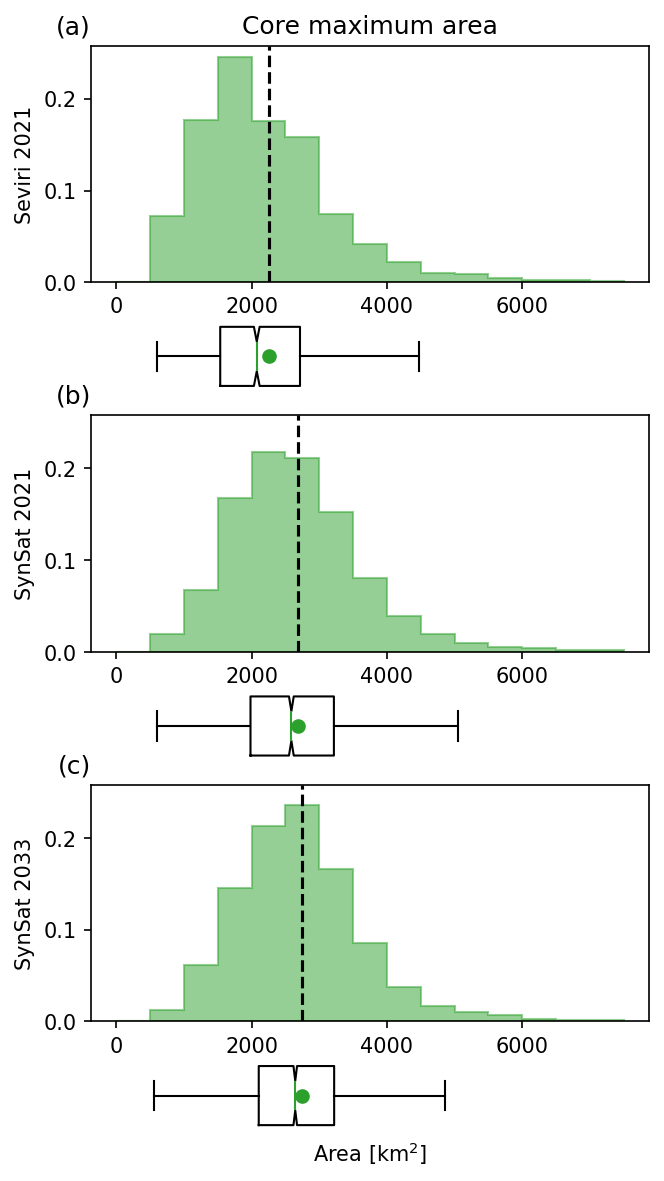

In [11]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 1, figsize=(4.8, 9.6), dpi=150, sharey=True)

color = "C2"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

axes[0].set_ylabel("Seviri 2021")
axes[1].set_ylabel("SynSat 2021")
axes[2].set_ylabel("SynSat 2033")

axes[2].set_xlabel("Area [km$^2$]", labelpad=40)

axes[0].set_title("Core maximum area", pad=20)

axes[0].set_title("(a)", loc="left", ha="right")
axes[1].set_title("(b)", loc="left", ha="right")
axes[2].set_title("(c)", loc="left", ha="right")

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    histogram_with_boxplot(
        ds.core_max_area[core_is_valid(ds)], 
        bins=core_area_bins,
        proportion=True, 
        ax=ax, 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

plt.subplots_adjust(hspace=0)

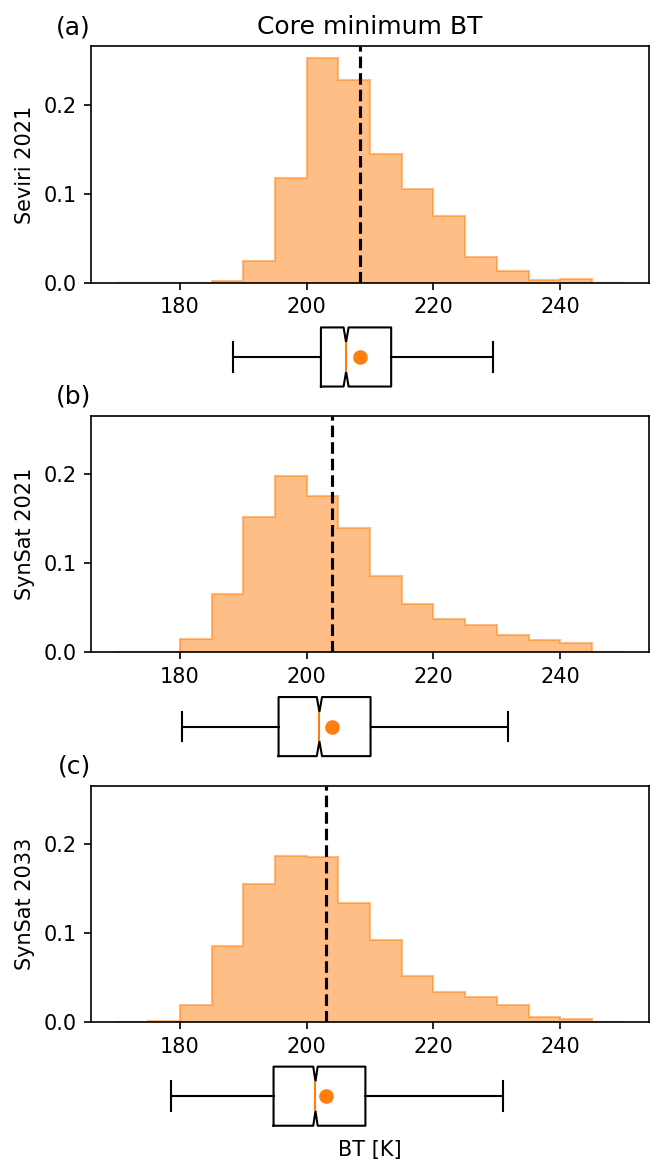

In [12]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 1, figsize=(4.8, 9.6), dpi=150, sharey=True)

color = "C1"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

axes[0].set_ylabel("Seviri 2021")
axes[1].set_ylabel("SynSat 2021")
axes[2].set_ylabel("SynSat 2033")

axes[2].set_xlabel("BT [K]", labelpad=40)

axes[0].set_title("Core minimum BT", pad=20)

axes[0].set_title("(a)", loc="left", ha="right")
axes[1].set_title("(b)", loc="left", ha="right")
axes[2].set_title("(c)", loc="left", ha="right")

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    histogram_with_boxplot(
        ds.core_bt_min[core_is_valid(ds)], 
        bins=core_bt_bins,
        proportion=True, 
        ax=ax, 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

plt.subplots_adjust(hspace=0)

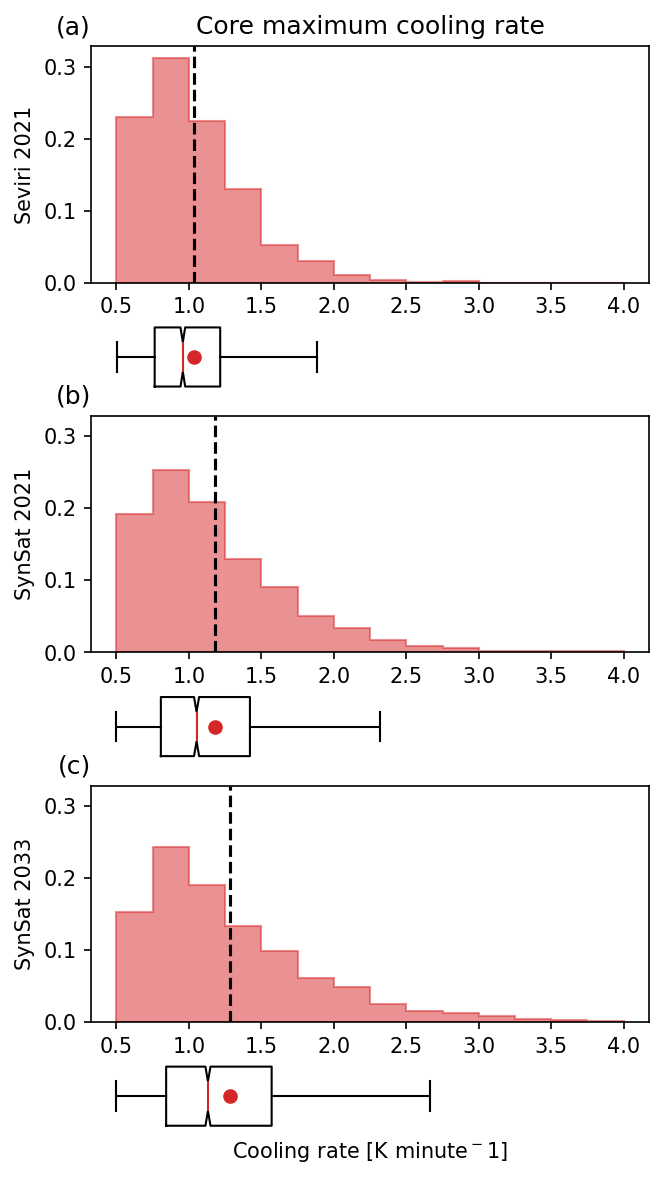

In [13]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 1, figsize=(4.8, 9.6), dpi=150, sharey=True)

color = "C3"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

axes[0].set_ylabel("Seviri 2021")
axes[1].set_ylabel("SynSat 2021")
axes[2].set_ylabel("SynSat 2033")

axes[2].set_xlabel("Cooling rate [K minute$^-1$]", labelpad=40)

axes[0].set_title("Core maximum cooling rate", pad=20)

axes[0].set_title("(a)", loc="left", ha="right")
axes[1].set_title("(b)", loc="left", ha="right")
axes[2].set_title("(c)", loc="left", ha="right")

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    histogram_with_boxplot(
        ds.core_max_cooling_rate[core_is_valid(ds)], 
        bins=core_cooling_rate_bins,
        proportion=True, 
        ax=ax, 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

plt.subplots_adjust(hspace=0)

In [14]:
lsm_file = "../../../manuscripts/conus_dataset_paper/data/lsm_data.nc"
lsm = xr.open_dataset(lsm_file).sea_mask.compute()

In [15]:
lsm.sel(
    lon = ds.core_start_lon,
    lat = ds.core_start_lat,
    method="nearest"
)

<xarray.DataArray 'sea_mask' (core: 7877)> Size: 8kB
array([ True,  True, False, ...,  True,  True,  True], shape=(7877,))
Coordinates:
    lon      (core) float64 63kB 180.0 43.65 27.75 51.25 ... 180.0 180.0 180.0
    lat      (core) float64 63kB -28.65 -4.35 0.45 3.05 ... 28.95 37.45 64.75
    crs      int64 8B 0
  * core     (core) int32 32kB 1 2 3 4 5 7 8 ... 8288 8289 8290 8291 8292 8293

In [16]:
def core_is_sea(ds):
    return lsm.sel(
        lon = ds.core_start_lon,
        lat = ds.core_start_lat,
        method="nearest"
    )

def anvil_is_sea(ds):
    return lsm.sel(
        lon = ds.thick_anvil_start_lon,
        lat = ds.thick_anvil_start_lat,
        method="nearest"
    )

In [17]:
def get_local_time(ds):
    local_time = ds.core_start_t + np.array(ds.core_start_lon/15*3600, "timedelta64[s]")
    return (
        local_time.dt.hour + local_time.dt.minute / 60 + local_time.dt.second / 3600
    )

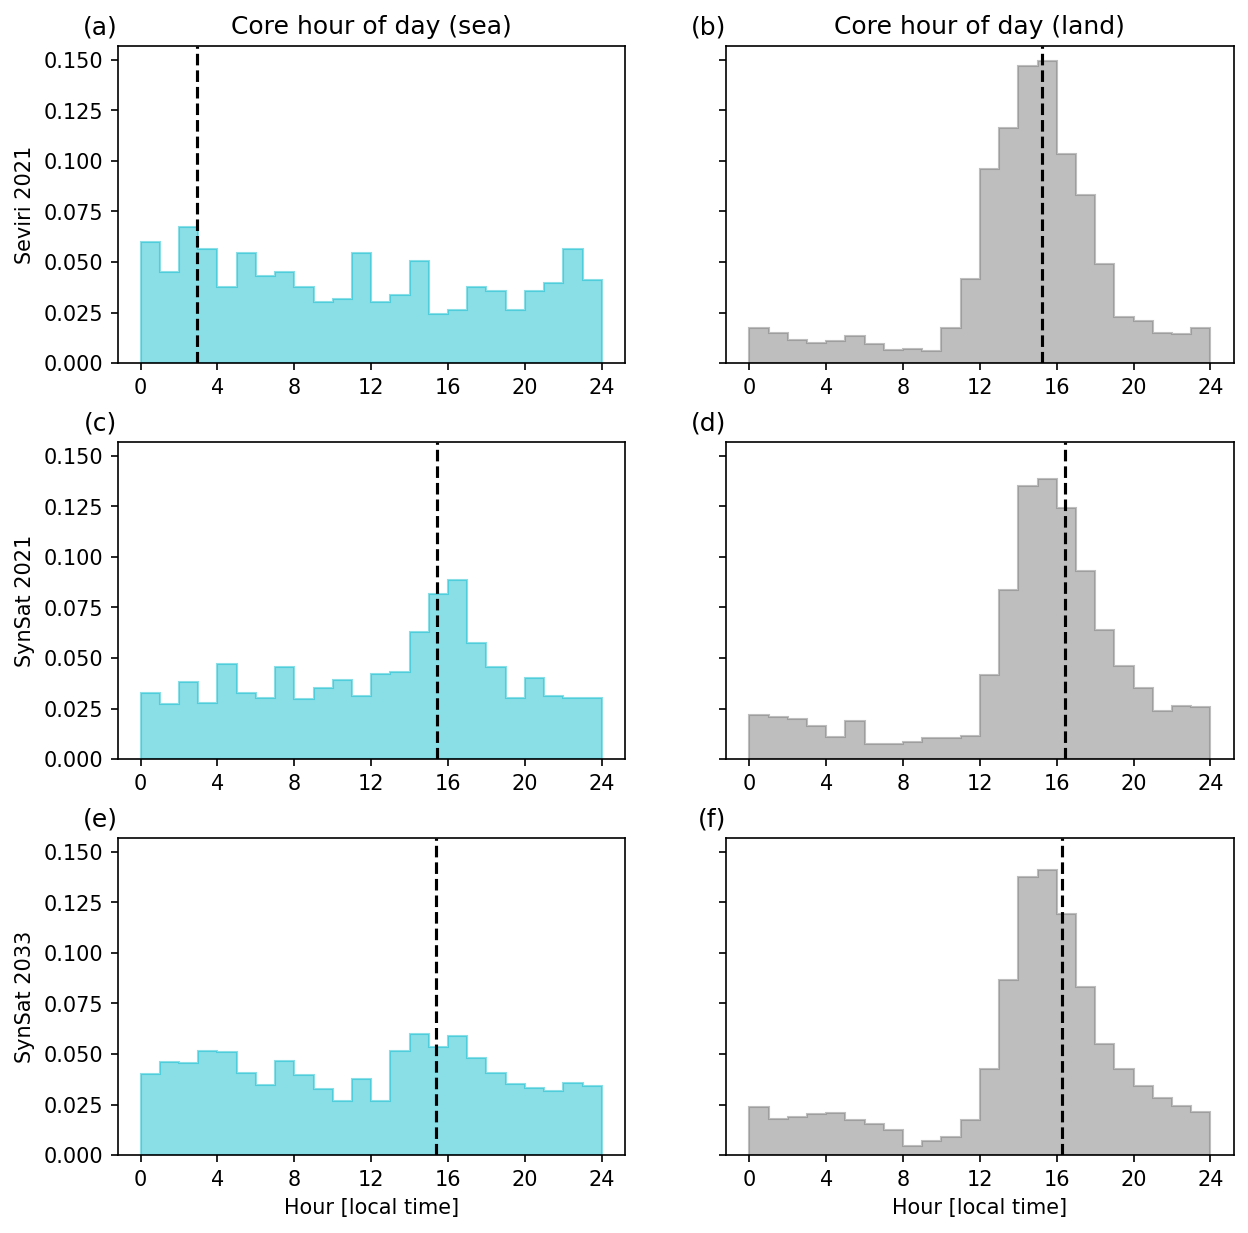

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(9.6, 9.6), dpi=150, sharey=True)


from string import ascii_lowercase

for ax, letter in zip(axes.ravel(), ascii_lowercase):
    ax.set_title(f'({letter})', loc="left", ha="right")
    ax.set_xticks(np.arange(0,25,4))

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    data = get_local_time(ds)[core_is_valid(ds) & core_is_sea(ds)]
    ax[0].hist(
        data,
        bins=hour_bins,
        weights=np.ones(data.shape)/data.size, 
        alpha=0.5, facecolor="C9", edgecolor="C9", ls='solid', lw=2, histtype='stepfilled'
    )
    ax[0].axvline(circmean_hour(data), color="k", linestyle="--")

    data = get_local_time(ds)[core_is_valid(ds) & ~core_is_sea(ds)]
    ax[1].hist(
        data,
        bins=hour_bins,
        weights=np.ones(data.shape)/data.size, 
        alpha=0.5, facecolor="C7", edgecolor="C7", ls='solid', lw=2, histtype='stepfilled'
    )
    ax[1].axvline(circmean_hour(data), color="k", linestyle="--")

axes[0, 0].set_ylabel("Seviri 2021")
axes[1, 0].set_ylabel("SynSat 2021")
axes[2, 0].set_ylabel("SynSat 2033")

axes[2, 0].set_xlabel("Hour [local time]")
axes[2, 1].set_xlabel("Hour [local time]")

axes[0, 0].set_title("Core hour of day (sea)")
axes[0, 1].set_title("Core hour of day (land)")


plt.subplots_adjust(hspace=0.25)

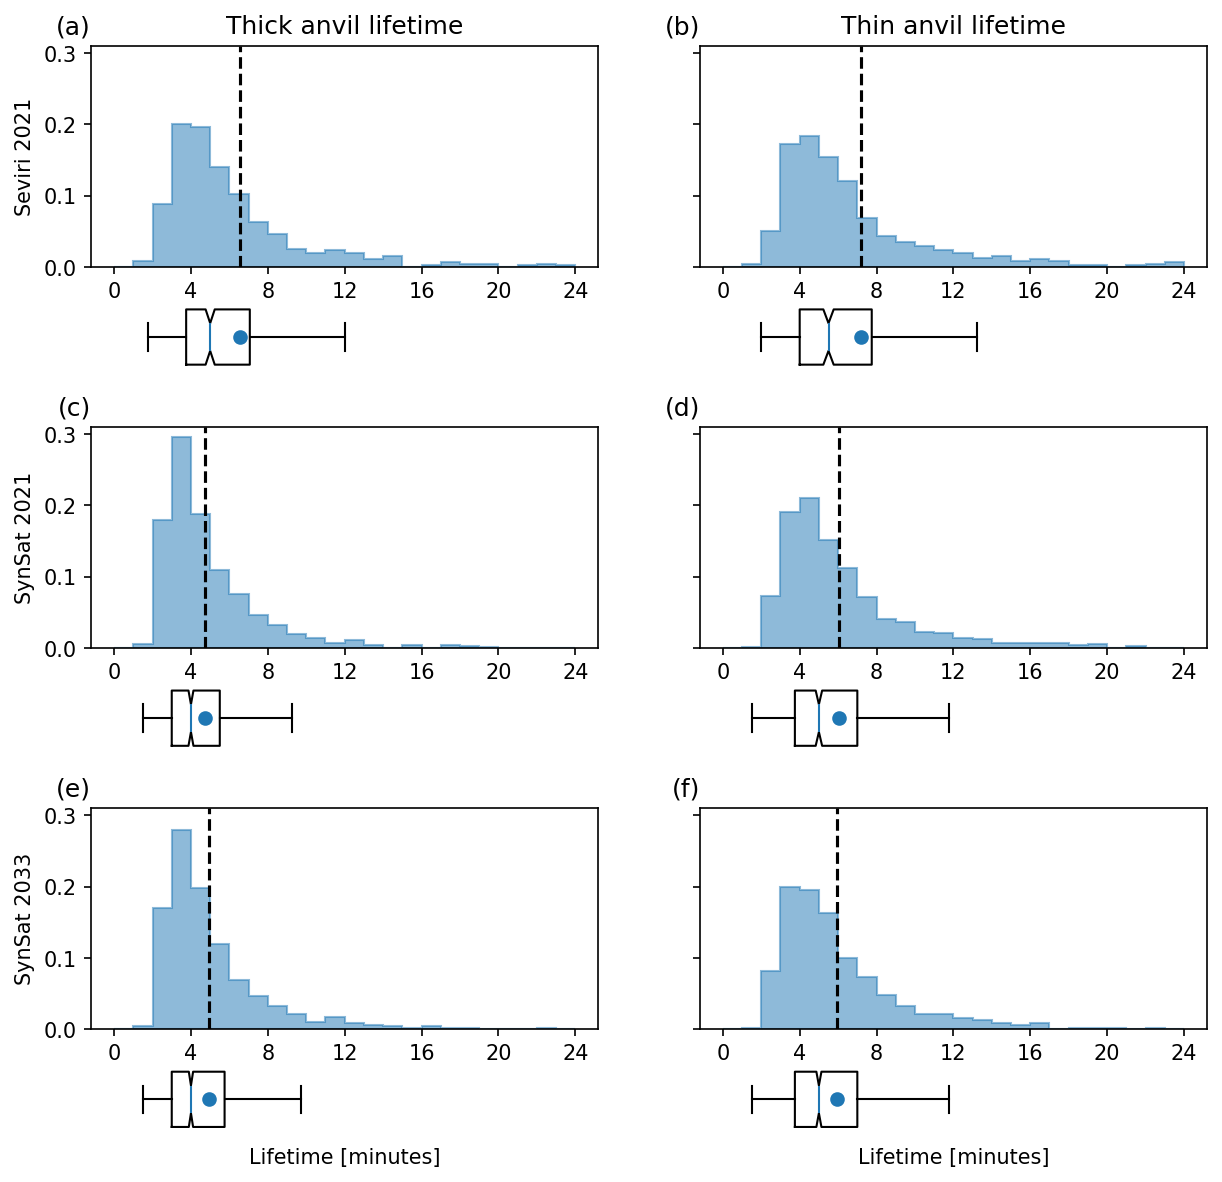

In [31]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 2, figsize=(9.6, 9.6), dpi=150, sharey=True)

from string import ascii_lowercase

for ax, letter in zip(axes.ravel(), ascii_lowercase):
    ax.set_title(f'({letter})', loc="left", ha="right")
    ax.set_xticks(np.arange(0,25,4))

color = "C0"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    data = get_local_time(ds)[core_is_valid(ds) & core_is_sea(ds)]
    histogram_with_boxplot(
        ds.thick_anvil_lifetime.astype(int)[anvil_is_valid(ds)]/3.6e12, 
        bins=thick_anvil_lifetime_bins,
        proportion=True, 
        ax=ax[0], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )
    
    histogram_with_boxplot(
        ds.thin_anvil_lifetime.astype(int)[anvil_is_valid(ds)]/3.6e12, 
        bins=thick_anvil_lifetime_bins,
        proportion=True, 
        ax=ax[1], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

axes[0, 0].set_ylabel("Seviri 2021")
axes[1, 0].set_ylabel("SynSat 2021")
axes[2, 0].set_ylabel("SynSat 2033")

axes[2, 0].set_xlabel("Lifetime [minutes]", labelpad=40)
axes[2, 1].set_xlabel("Lifetime [minutes]", labelpad=40)

axes[0, 0].set_title("Thick anvil lifetime")
axes[0, 1].set_title("Thin anvil lifetime")

plt.subplots_adjust(hspace=0.1)

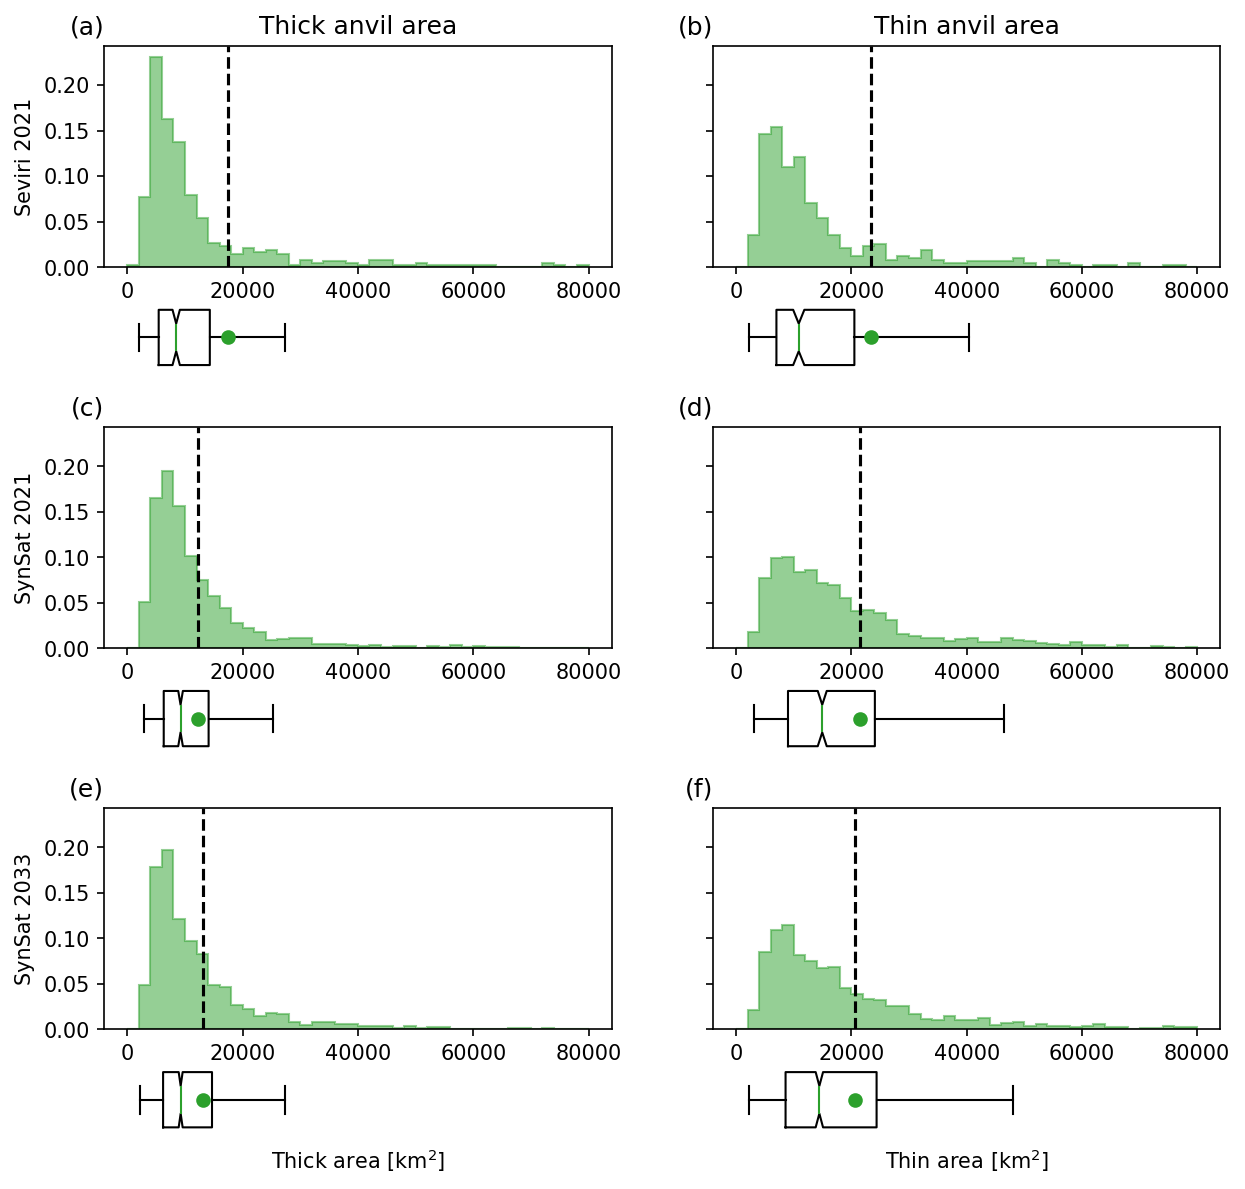

In [35]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 2, figsize=(9.6, 9.6), dpi=150, sharey=True)

from string import ascii_lowercase

for ax, letter in zip(axes.ravel(), ascii_lowercase):
    ax.set_title(f'({letter})', loc="left", ha="right")

color = "C2"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    data = get_local_time(ds)[core_is_valid(ds) & core_is_sea(ds)]
    histogram_with_boxplot(
        ds.thick_anvil_max_area[anvil_is_valid(ds)], 
        bins=thick_anvil_area_bins,
        proportion=True, 
        ax=ax[0], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )
    
    histogram_with_boxplot(
        ds.thin_anvil_max_area[anvil_is_valid(ds)], 
        bins=thick_anvil_area_bins,
        proportion=True, 
        ax=ax[1], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs, 
        boxplot_kwargs=boxplot_kwargs, 
        show_meanline=True
    )

axes[0, 0].set_ylabel("Seviri 2021")
axes[1, 0].set_ylabel("SynSat 2021")
axes[2, 0].set_ylabel("SynSat 2033")

axes[2, 0].set_xlabel("Thick area [$\mathrm{km^2}$]", labelpad=40)
axes[2, 1].set_xlabel("Thin area [$\mathrm{km^2}$]", labelpad=40)

axes[0, 0].set_title("Thick anvil area")
axes[0, 1].set_title("Thin anvil area")

plt.subplots_adjust(hspace=0.1)

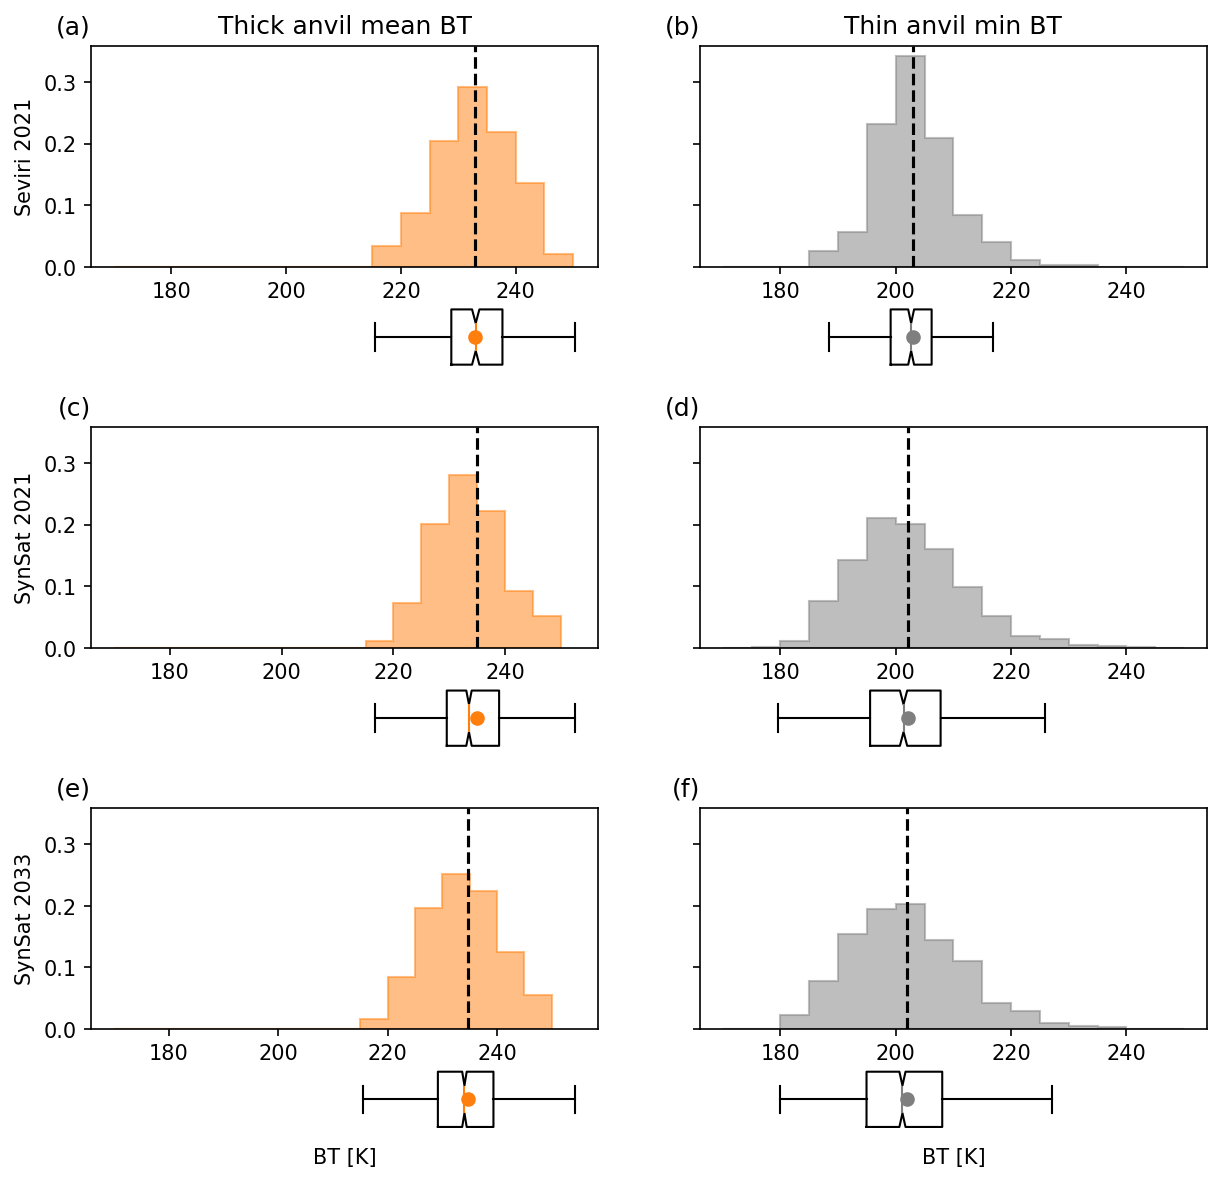

In [36]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 2, figsize=(9.6, 9.6), dpi=150, sharey=True)

from string import ascii_lowercase

for ax, letter in zip(axes.ravel(), ascii_lowercase):
    ax.set_title(f'({letter})', loc="left", ha="right")

color = "C1"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs_0=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs_0=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

color = "C7"
hist_kwargs_1=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2, histtype='stepfilled')
boxplot_kwargs_1=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):
    data = get_local_time(ds)[core_is_valid(ds) & core_is_sea(ds)]
    histogram_with_boxplot(
        ds.thick_anvil_bt_mean[anvil_is_valid(ds)], 
        bins=core_bt_bins,
        proportion=True, 
        ax=ax[0], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs_0, 
        boxplot_kwargs=boxplot_kwargs_0, 
        show_meanline=True
    )
    
    histogram_with_boxplot(
        ds.thick_anvil_bt_min[anvil_is_valid(ds)], 
        bins=core_bt_bins,
        proportion=True, 
        ax=ax[1], 
        axes_kwargs=axes_kwargs, 
        hist_kwargs=hist_kwargs_1, 
        boxplot_kwargs=boxplot_kwargs_1, 
        show_meanline=True
    )

axes[0, 0].set_ylabel("Seviri 2021")
axes[1, 0].set_ylabel("SynSat 2021")
axes[2, 0].set_ylabel("SynSat 2033")

axes[2, 0].set_xlabel("BT [K]", labelpad=40)
axes[2, 1].set_xlabel("BT [K]", labelpad=40)

axes[0, 0].set_title("Thick anvil mean BT")
axes[0, 1].set_title("Thin anvil min BT")

plt.subplots_adjust(hspace=0.1)

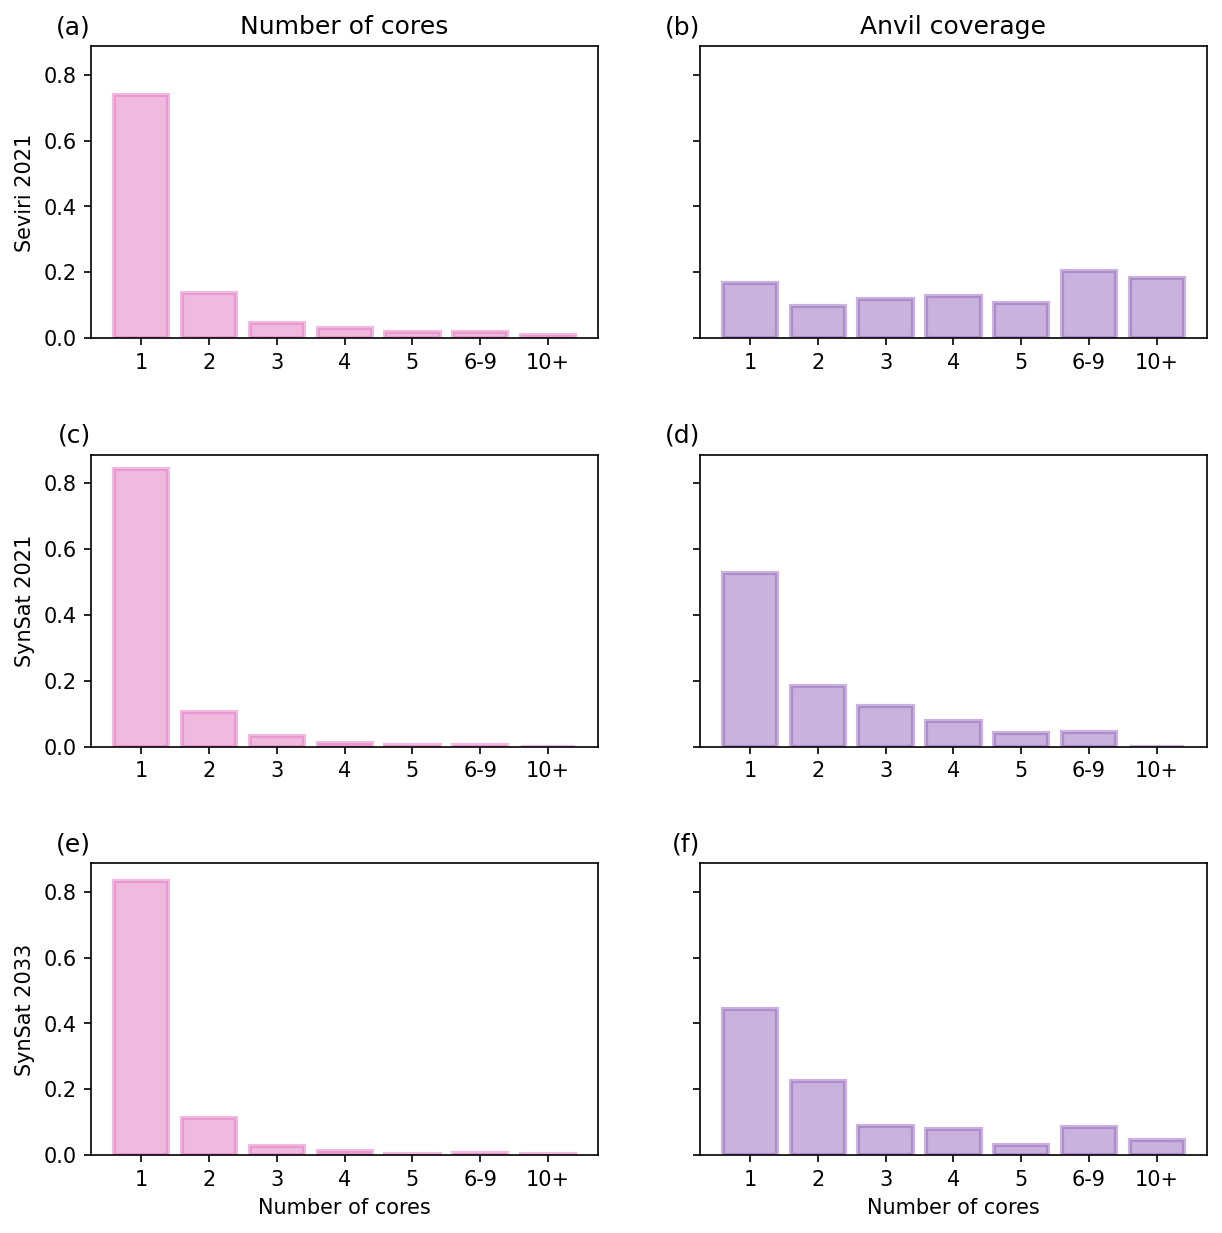

In [51]:
# plt.xlabel("Lifetime [minutes]", labelpad=25)
fig, axes = plt.subplots(3, 2, figsize=(9.6, 9.6), dpi=150, sharey=True)

from string import ascii_lowercase

for ax, letter in zip(axes.ravel(), ascii_lowercase):
    ax.set_title(f'({letter})', loc="left", ha="right")

color = "C6"
axes_kwargs=dict(size="50%", pad=0.1)
hist_kwargs_0=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2)
boxplot_kwargs_0=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

color = "C4"
hist_kwargs_1=dict(alpha=0.5, facecolor=color, edgecolor=color, ls='solid', lw=2)
boxplot_kwargs_1=dict(notch=True, sym="", widths=0.5, medianprops=dict(color=color), showmeans=True, meanprops=dict(mfc=color, mec=color, marker="o"))

bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 9.5, 999999]
bin_positions = [1, 2, 3, 4, 5, 6, 7]
bin_labels = [1, 2, 3, 4, 5, "6-9", "10+"]

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):

    bar_data = np.histogram(ds.anvil_core_count[anvil_is_valid(ds)], bins=bins)[0] / anvil_is_valid(ds).values.sum()

    ax[0].bar(
        bin_positions, 
        bar_data,
        **hist_kwargs_0
    )

    bar_data = np.histogram(
        ds.anvil_core_count[anvil_is_valid(ds)], 
        weights=ds.thick_anvil_total_area[anvil_is_valid(ds)], 
        bins=bins
    )[0] / ds.thick_anvil_total_area[anvil_is_valid(ds)].values.sum()

    ax[1].bar(
        bin_positions, 
        bar_data,
        **hist_kwargs_1
    )


axes[0, 0].set_ylabel("Seviri 2021")
axes[1, 0].set_ylabel("SynSat 2021")
axes[2, 0].set_ylabel("SynSat 2033")

axes[0, 0].set_xticks(bin_positions, bin_labels)
axes[0, 1].set_xticks(bin_positions, bin_labels)
axes[1, 0].set_xticks(bin_positions, bin_labels)
axes[1, 1].set_xticks(bin_positions, bin_labels)
axes[2, 0].set_xticks(bin_positions, bin_labels)
axes[2, 1].set_xticks(bin_positions, bin_labels)

axes[2, 0].set_xlabel("Number of cores")
axes[2, 1].set_xlabel("Number of cores")

axes[0, 0].set_title("Number of cores")
axes[0, 1].set_title("Anvil coverage")

plt.subplots_adjust(hspace=0.4)

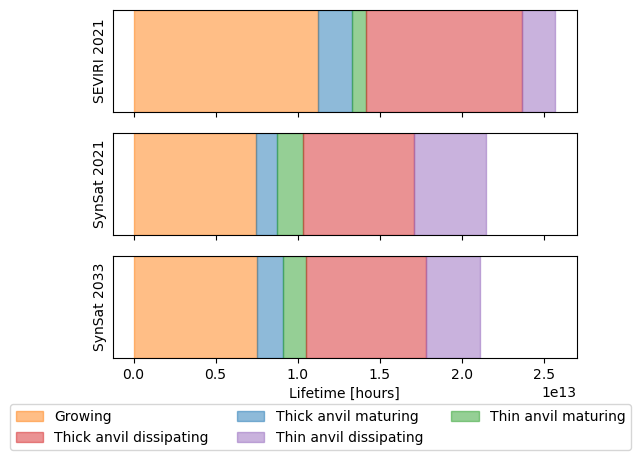

In [70]:
fig, axes = plt.subplots(3, 1, sharex=True)

for ds, ax in zip([seviri_2021_ds, synsat_2021_ds, synsat_2033_ds], axes):

    min_bt_t = np.nanmean((ds.thick_anvil_min_bt_t - ds.thick_anvil_start_t)[anvil_is_valid(ds)].values)
    max_thick_area_t = np.nanmean((ds.thick_anvil_max_area_t - ds.thick_anvil_start_t)[anvil_is_valid(ds)].values)
    max_thin_area_t = np.nanmean((ds.thin_anvil_max_area_t - ds.thick_anvil_start_t)[anvil_is_valid(ds)].values)
    thick_lifetime_t = np.nanmean((ds.thick_anvil_end_t - ds.thick_anvil_start_t)[anvil_is_valid(ds)].values)
    thin_lifetime_t = np.nanmean((ds.thin_anvil_end_t - ds.thick_anvil_start_t)[anvil_is_valid(ds)].values)

    f1 = ax.fill_between([0,min_bt_t],[0,0],[1,1],color="C1",alpha=0.5)
    # ax.axvline(x=min_bt_t, color='k', linestyle="--", linewidth=1.5)
    
    f2 = ax.fill_between([min_bt_t, max_thick_area_t],[0,0],[1,1],
                    color="C0",alpha=0.5)
    # ax.axvline(x=max_thick_area_t, color='k', linestyle="--", linewidth=1.5)
    
    f3 = ax.fill_between([max_thick_area_t, max_thin_area_t],[0,0],[1,1],
                    color="C2",alpha=0.5)
    # ax.axvline(x=max_thin_area_t, color='k', linestyle="--", linewidth=1.5)
    
    f4 = ax.fill_between([max_thin_area_t, thick_lifetime_t],[0,0],[1,1],
                    color="C3",alpha=0.5)
    # ax.axvline(x=thick_lifetime_t, color='k', linestyle="--", linewidth=1.5)
    
    f5 = ax.fill_between([thick_lifetime_t, thin_lifetime_t],[0,0],[1,1],
                    color="C4",alpha=0.5)

    ax.set_yticks([])
    ax.set_ylim([0,1])
    # ax.set_xlim([0,7.5])

plt.xlabel("Lifetime [hours]")

axes[0].set_ylabel("SEVIRI 2021")
axes[1].set_ylabel("SynSat 2021")
axes[2].set_ylabel("SynSat 2033")



fig.legend(
    [f1,f4,f2,f5,f3], 
    ["Growing", "Thick anvil dissipating", "Thick anvil maturing", "Thin anvil dissipating", "Thin anvil maturing"],
    loc="lower center", ncol=3
)

plt.subplots_adjust(left=0.175, top=0.925,  bottom=0.2)


In [60]:
min_bt_t

np.timedelta64(11242472916666,'ns')

In [ ]:
ds.thick_anvil_start_t

In [ ]:
fig, axes = plt.subplots(7, 1, sharex=True, dpi=dpi)

for i in range(1,8):
    wh = np.logical_and(
        initial_core_cooling_rate >= anvil_cooling_bins[i-1], 
        initial_core_cooling_rate < anvil_cooling_bins[i]
    )
        
    wh = np.logical_and(wh, anvil_is_valid)
    
    ylabel = [anvil_cooling_labels[i-1]]
        
    ax = axes[i-1]
    
    min_bt_t = np.nanmean(anvil_time_to_min_BT[wh])
    max_thick_area_t = np.nanmean(anvil_time_to_max_thick_area[wh])
    max_thin_area_t = np.nanmean(anvil_time_to_max_thin_area[wh])
    thick_lifetime_t = np.nanmean(thick_anvil_lifetime[wh])
    thin_lifetime_t = np.nanmean(thin_anvil_lifetime[wh])
    
    f1 = ax.fill_between([0,min_bt_t],[0,0],[1,1],color="C1",alpha=0.5)
    ax.axvline(x=min_bt_t, color='k', linestyle="--", linewidth=1.5)
    
    f2 = ax.fill_between([min_bt_t, max_thick_area_t],[0,0],[1,1],
                    color="C0",alpha=0.5)
    ax.axvline(x=max_thick_area_t, color='k', linestyle="--", linewidth=1.5)
    
    f3 = ax.fill_between([max_thick_area_t, max_thin_area_t],[0,0],[1,1],
                    color="C2",alpha=0.5)
    ax.axvline(x=max_thin_area_t, color='k', linestyle="--", linewidth=1.5)
    
    f4 = ax.fill_between([max_thin_area_t, thick_lifetime_t],[0,0],[1,1],
                    color="C3",alpha=0.5)
    ax.axvline(x=thick_lifetime_t, color='k', linestyle="--", linewidth=1.5)
    
    f5 = ax.fill_between([thick_lifetime_t, thin_lifetime_t],[0,0],[1,1],
                    color="C4",alpha=0.5)
    ax.axvline(x=thin_lifetime_t, color='k', linestyle="-", linewidth=1.5)
    
    ax.set_xlim([0,4.5])
    ax.set_yticks([0.5], ylabel)
    ax.set_ylim([0,1])

plt.xlabel("Lifetime [hours]")

plt.suptitle("  DCC lifecycle by number of cores")

fig.legend(
    [f1,f4,f2,f5,f3], 
    ["Growing", "Thick anvil dissipating", "Thick anvil maturing", "Thin anvil dissipating", "Thin anvil maturing"],
    loc="lower center", ncol=3
)

plt.subplots_adjust(left=0.175, top=0.925,  bottom=0.2)

fig.text(0.05, 0.55, "Initial core cooling rate [$K/minute$]", rotation="vertical", ha="center", va="center")
